In [22]:
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
d1 = pd.read_csv(gzip.open("data/GSE128365/GSM4364035_SupplementaryData_HeatShock_37C-labeled-EU-45min-K562-plate2_umiCount_spliced.csv.gz"), index_col=0)
d1 = d1[d1.columns[4:]]
d2 = pd.read_csv(gzip.open("data/GSE128365/GSM4364035_SupplementaryData_HeatShock_37C-labeled-EU-45min-K562-plate2_umiCount_unspliced.csv.gz"), index_col=0)
d2 = d2[d2.columns[4:]]

/home/chenzonggui/tmp/ipykernel_13939/3080570267.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  d1 = pd.read_csv(gzip.open("data/GSE128365/GSM4364035_SupplementaryData_HeatShock_37C-labeled-EU-45min-K562-plate2_umiCount_spliced.csv.gz"), index_col=0)


In [33]:
d3 = d1 + d2

In [34]:
vs = d3.sum()
vs = vs[vs > 1000]
print(np.mean(vs), np.median(vs))

5257.116883116883 4692.0


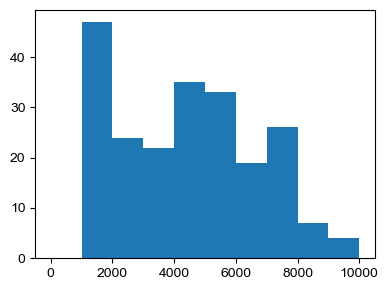

In [35]:
plt.figure(figsize=(4, 3))
plt.hist(vs, range=(0, 10000))
plt.tight_layout()
plt.show()

In [36]:
d4 = d3[vs.index]

In [40]:
genes = (d4 > 0).sum()

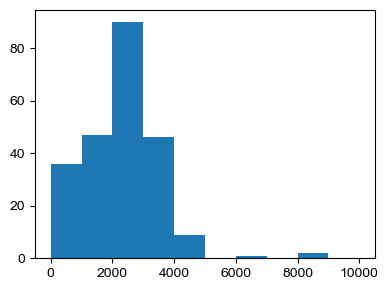

In [42]:
plt.figure(figsize=(4, 3))
plt.hist(genes, range=(0, 10000))
plt.tight_layout()
plt.show()

In [43]:
np.mean(genes), np.median(genes)

(2325.064935064935, 2348.0)

# UMIs of cells at different cell cycle

In [31]:
import numpy as np
import pandas as pd
import gzip
import matplotlib.pyplot as plt

In [3]:
d = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_CelSeq2.csv.gz", "rt"), sep=",")
d

,plate_id,1.0,1.0.1,1.0.2,1.0.3,1.0.4,1.0.5,1.0.6,1.0.7,1.0.8,...,4.0.374,4.0.375,4.0.376,4.0.377,4.0.378,4.0.379,4.0.380,4.0.381,4.0.382,4.0.383
0,cell_id,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,...,374.000000,375.000000,376.000000,377.000000,378.000000,379.000000,380.000000,381.000000,382.000000,383.0
1,rfp_levels,2.689221,529.736696,4.205129,281.331751,356.402645,4.176857,790.919575,6.198654,37.379358,...,167.823787,4.004978,991.045856,434.510713,167.211677,10.145808,629.787934,526.027320,3.165835,0.0
2,gfp_levels,32.346453,2.236080,157.450323,515.054312,1200.960735,52.943899,761.577083,1232.767986,2465.509829,...,490.677223,71.711832,16.173398,2.031137,825.094907,1376.749668,28.760820,54.163113,2133.543797,0.0
3,log10_rfp_levels,0.429626,2.724060,0.623779,2.449219,2.551941,0.620850,2.898132,0.792297,1.572632,...,2.224854,0.602600,2.996094,2.638000,2.223267,1.006287,2.799194,2.721008,0.500488,-1.0
4,log10_gfp_levels,1.509827,0.349487,2.197144,2.711853,3.079529,1.723816,2.881714,3.090881,3.391907,...,2.690796,1.855591,1.208801,0.307739,2.916504,3.138855,1.458801,1.733704,3.329102,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24582,ENSG00000284727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
24583,ENSG00000284737,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
24584,ENSG00000284738,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
24585,ENSG00000284741,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [28]:
meta = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_metadata.csv.gz", "rt"), sep=",", index_col=0).T
meta["Cell_cycle_relativePos"] = meta["Cell_cycle_relativePos"].astype(float)

In [19]:
m1 = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_labeled_splicedUMI.csv.gz"), index_col=0).T
m2 = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_labeled_unsplicedUMI.csv.gz"), index_col=0).T
m3 = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_unlabeled_splicedUMI.csv.gz"), index_col=0).T
m4 = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_unlabeled_unsplicedUMI.csv.gz"), index_col=0).T

In [25]:
s1 = m1.sum(axis=1)
s1.name = "labeled_splice"
s2 = m2.sum(axis=1)
s2.name = "labeled_unsplice"
s3 = m3.sum(axis=1)
s3.name = "unlabeled_splice"
s4 = m4.sum(axis=1)
s4.name = "unlabeled_unsplice"

In [29]:
m = pd.concat([meta, s1, s2, s3, s4], axis=1)

In [30]:
m

,Plate_Id,Condition_Id,Well_Id,RFP_log10_corrected,GFP_log10_corrected,Cell_cycle_possition,Cell_cycle_relativePos,labeled_splice,labeled_unsplice,unlabeled_splice,unlabeled_unsplice
Cell_00001,plate01,Chase_360,2.0,1.088041666852412,2.9694767817260765,105.0,0.350000,1206.0,198.0,7354.0,1064.0
Cell_00002,plate01,Chase_120,9.0,0.8986272417761243,3.16150620502695,101.0,0.336667,2673.0,526.0,6765.0,866.0
Cell_00003,plate01,Chase_120,12.0,0.5464935292310066,3.2866533107682425,93.0,0.310000,772.0,76.0,1964.0,146.0
Cell_00004,plate01,Chase_60,14.0,1.097916956420803,2.6539723106228985,89.0,0.296667,3342.0,711.0,7170.0,1065.0
Cell_00005,plate01,Chase_60,17.0,1.0521083551325905,3.0418897524684665,104.0,0.346667,6027.0,1328.0,7584.0,1049.0
...,...,...,...,...,...,...,...,...,...,...,...
Cell_05418,plate10,Pulse_120,376.0,0.6624145507812502,1.96307373046875,40.0,0.133333,1549.0,1191.0,7504.0,933.0
Cell_05419,plate10,Pulse_120,377.0,0.9138793945312502,3.0484619140625013,98.0,0.326667,809.0,484.0,3968.0,469.0
Cell_05420,plate10,Pulse_180,379.0,2.4844970703125,3.11181640625,176.0,0.586667,2598.0,1608.0,8187.0,1054.0
Cell_05421,plate10,Pulse_180,380.0,0.4707031249999996,3.2412719726562487,91.0,0.303333,3497.0,1984.0,12183.0,1542.0


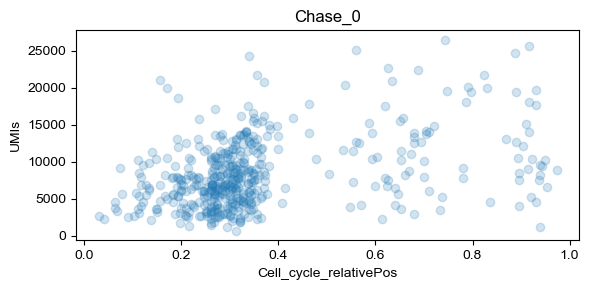

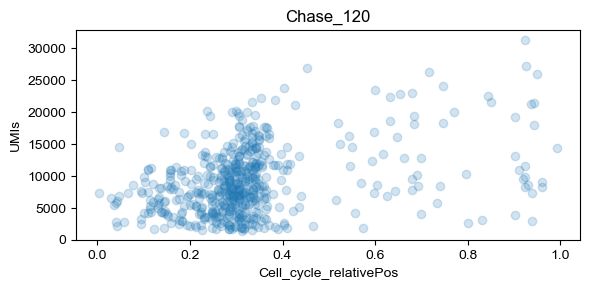

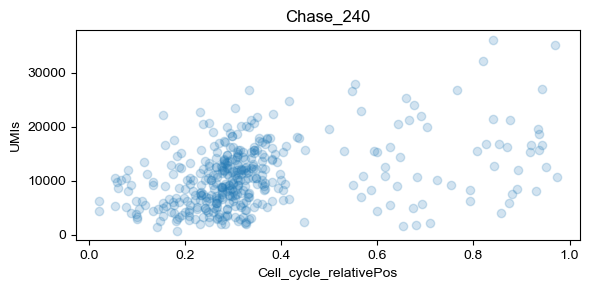

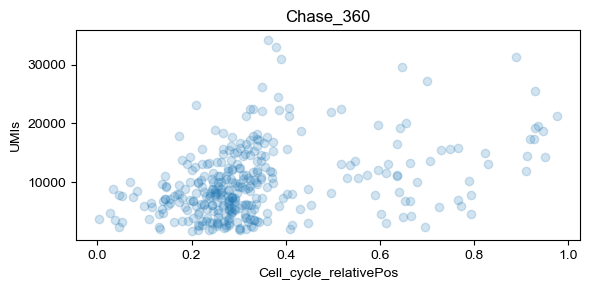

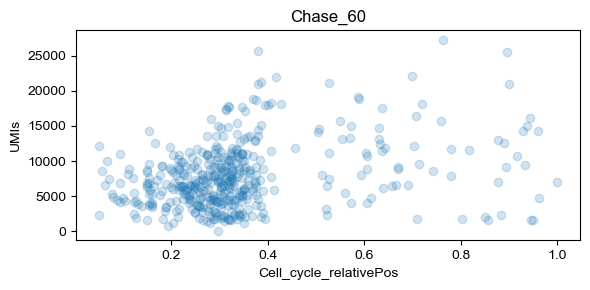

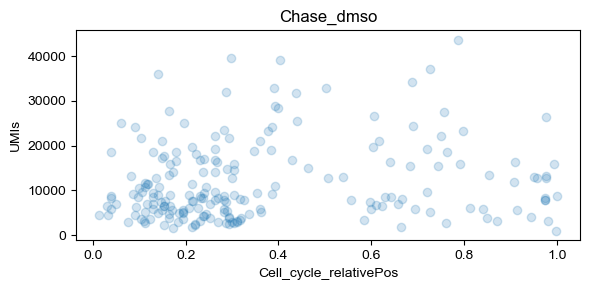

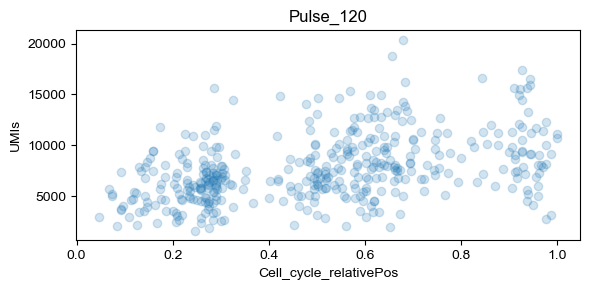

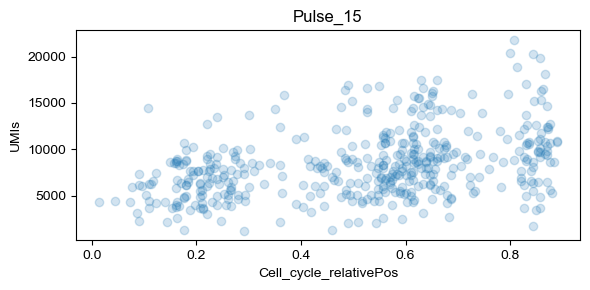

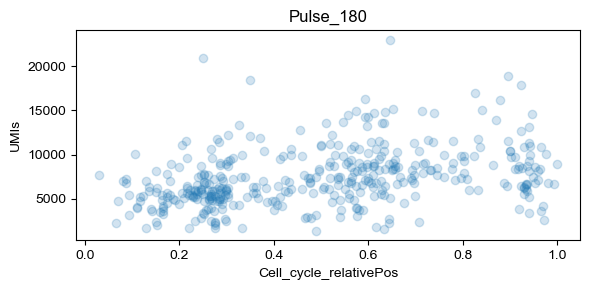

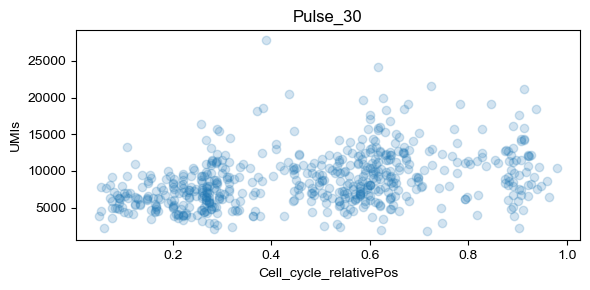

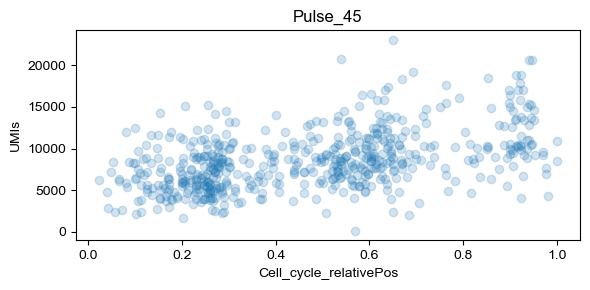

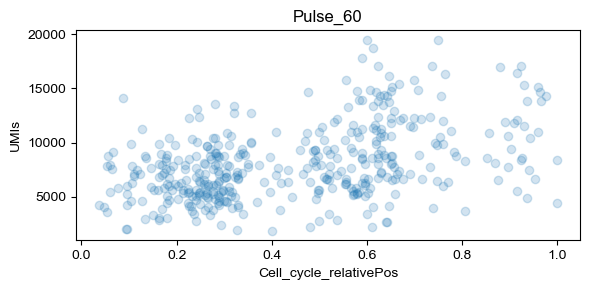

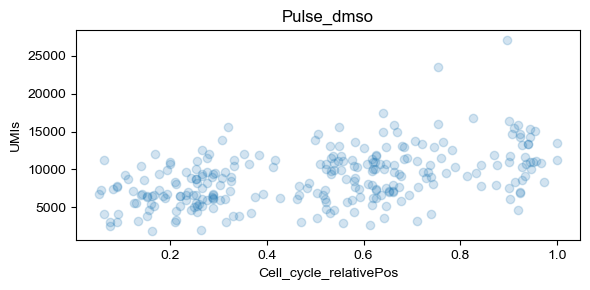

In [41]:
for c, tmp in m.groupby(by="Condition_Id"):
    xs = tmp["Cell_cycle_relativePos"]
    # ys = tmp["labeled_splice"] # + tmp["labeled_unsplice"] + tmp["unlabeled_splice"] + tmp["unlabeled_unsplice"]
    ys = tmp["unlabeled_splice"]
    plt.figure(figsize=(6, 3))
    plt.title(c)
    plt.scatter(xs, ys, alpha=0.2)
    plt.xlabel("Cell_cycle_relativePos")
    plt.ylabel("UMIs")
    plt.tight_layout()
    plt.show()

# Cell cycle progression

In [1]:
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
d = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_metadata.csv.gz"), index_col=0).T

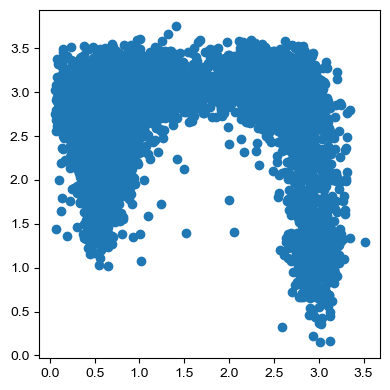

In [13]:
ys = d["GFP_log10_corrected"].astype(float)
xs = d["RFP_log10_corrected"].astype(float)
plt.figure(figsize=(4, 4))
plt.scatter(xs, ys)
plt.tight_layout()
plt.show()

In [15]:
d = pd.read_csv(gzip.open("data/GSE128365_SupplementaryData_RPE1_labeled_splicedUMI.csv.gz"), index_col=0)
d

,Cell_00001,Cell_00002,Cell_00003,Cell_00004,Cell_00005,Cell_00006,Cell_00007,Cell_00008,Cell_00009,Cell_00010,...,Cell_05413,Cell_05414,Cell_05415,Cell_05416,Cell_05417,Cell_05418,Cell_05419,Cell_05420,Cell_05421,Cell_05422
Gene_Id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000000419,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000000457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000000460,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000000971,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000284634,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000284681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000284683,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
